# Thống Kê Entropy - First N Tokens (Tiếng Việt)

Notebook này thu thập giá trị entropy chỉ sử dụng N token đầu tiên (N=5) từ responses.

## Mục tiêu:
1. Sử dụng cùng dataset như phân tích full_token để đảm bảo nhất quán
2. Gọi API 1 lần mỗi query (n=1) để tiết kiệm token
3. Tính entropy chỉ từ 5 token đầu tiên
4. So sánh kết quả với phương pháp full_token


## Cell 1: Setup và Import


In [2]:
import sys
import os
import json
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent.parent
sys.path.insert(0, str(project_root))

# Add current directory to path for local module
current_dir = Path().absolute()
sys.path.insert(0, str(current_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from typing import List, Dict

# Set matplotlib để xử lý font tiếng Việt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Import custom entropy calculation module (từ thư mục hiện tại)
from entropy_first_n_token import calculate_entropy_from_response

print("Setup hoàn tất!")


Setup hoàn tất!


## Cell 2: Import Modules và Load Queries


In [3]:
from backend.models.adaptive_controller import AdaptiveController
from backend.config.config import get_config

# Khởi tạo adaptive controller
config = get_config()
controller = AdaptiveController(
    k_min=config.adaptive.k_min,
    k_max=config.adaptive.k_max
)

# Load test queries từ JSON (cùng dataset như full_token analysis)
queries_file = Path("test_queries_vi.json")
with open(queries_file, 'r', encoding='utf-8') as f:
    test_queries = json.load(f)

# Flatten queries thành list với categories
all_queries = []
for category, queries in test_queries.items():
    for query in queries:
        all_queries.append({
            'query': query,
            'difficulty': category
        })

print(f"Đã load {len(all_queries)} queries")
print(f"  - Dễ: {len([q for q in all_queries if q['difficulty'] == 'dễ'])}")
print(f"  - Trung bình: {len([q for q in all_queries if q['difficulty'] == 'trung_bình'])}")
print(f"  - Khó: {len([q for q in all_queries if q['difficulty'] == 'khó'])}")
print(f"\nSử dụng n_iterations = 1 để tiết kiệm token")
print(f"Sử dụng N = 5 token đầu tiên để tính entropy")


Đã load 101 queries
  - Dễ: 34
  - Trung bình: 34
  - Khó: 33

Sử dụng n_iterations = 1 để tiết kiệm token
Sử dụng N = 5 token đầu tiên để tính entropy


## Cell 3: Thu thập Entropy Data (n=1, first 5 tokens)


In [4]:
from backend.services.llm_service import generate_with_logprobs
from backend.models.adaptive_controller import _build_style_prompt

def collect_entropy_data_first_n(
    queries: List[Dict], 
    language: str = "vi", 
    n_iterations: int = 1,
    num_tokens: int = 5
) -> pd.DataFrame:
    """
    Thu thập entropy values từ queries sử dụng N token đầu tiên.
    Gọi API n_iterations lần (mặc định 1 để tiết kiệm token).
    
    Returns:
        DataFrame với columns: sample_id, query, difficulty, entropy (first N tokens)
    """
    results = []
    
    print(f"Bắt đầu thu thập entropy với n_iterations={n_iterations}, first {num_tokens} tokens...")
    print(f"Tổng số queries: {len(queries)}\n")
    
    for idx, item in enumerate(queries, 1):
        query = item['query']
        difficulty = item['difficulty']
        
        print(f"[{idx}/{len(queries)}] {difficulty}: {query[:50]}...")
        
        try:
            # Gọi API n_iterations lần
            entropies_per_iteration = []
            
            for iteration in range(n_iterations):
                # Sử dụng các styles khác nhau cho mỗi iteration (cycle through)
                style = config.adaptive.style_candidates[iteration % len(config.adaptive.style_candidates)]
                style_prompt = _build_style_prompt(query, style, language)
                
                # Gọi API trực tiếp để lấy logprobs
                # Tối ưu: chỉ generate num_tokens để tiết kiệm API calls
                gen_result = generate_with_logprobs(
                    query=query,
                    style_prompt=style_prompt,
                    language=language,
                    model=config.adaptive.phase1_model,
                    temperature=config.adaptive.phase1_temperature,
                    max_tokens=num_tokens  # Chỉ generate số token cần thiết
                )
                
                logprobs = gen_result.get("logprobs", [])
                if logprobs:
                    # Tính entropy từ N token đầu tiên
                    entropy = calculate_entropy_from_response(logprobs, num_tokens=num_tokens)
                    entropies_per_iteration.append(entropy)
            
            # Lấy entropy (giá trị đơn khi n_iterations=1, hoặc trung bình nếu >1)
            avg_entropy = sum(entropies_per_iteration) / len(entropies_per_iteration) if entropies_per_iteration else 0.0
            
            results.append({
                'sample_id': idx,
                'query': query,
                'difficulty': difficulty,
                'entropy': avg_entropy,
                'entropy_std': np.std(entropies_per_iteration) if len(entropies_per_iteration) > 1 else 0.0,
                'n_iterations': n_iterations,
                'num_tokens': num_tokens
            })
            
        except Exception as e:
            print(f"    LỖI: {str(e)}")
            results.append({
                'sample_id': idx,
                'query': query,
                'difficulty': difficulty,
                'entropy': None,
                'entropy_std': None,
                'error': str(e),
                'n_iterations': n_iterations,
                'num_tokens': num_tokens
            })
            continue
    
    return pd.DataFrame(results)

# Thu thập dữ liệu với n=1, first 5 tokens (để tiết kiệm token)
df_entropy = collect_entropy_data_first_n(all_queries, language="vi", n_iterations=1, num_tokens=5)

print(f"\n✓ Đã thu thập {len(df_entropy)} samples")
df_entropy.head(10)


Bắt đầu thu thập entropy với n_iterations=1, first 5 tokens...
Tổng số queries: 101

[1/101] dễ: python là gì?...
[2/101] dễ: git là gì?...
[3/101] dễ: ai là gì?...
[4/101] dễ: machine learning là gì?...
[5/101] dễ: deep learning là gì?...
[6/101] dễ: neural network là gì?...
[7/101] dễ: gan là gì?...
[8/101] dễ: transformer là gì?...
[9/101] dễ: cơ sở dữ liệu là gì?...
[10/101] dễ: thuật toán là gì?...
[11/101] dễ: java là gì?...
[12/101] dễ: javascript là gì?...
[13/101] dễ: html là gì?...
[14/101] dễ: css là gì?...
[15/101] dễ: sql là gì?...
[16/101] dễ: api là gì?...
[17/101] dễ: json là gì?...
[18/101] dễ: xml là gì?...
[19/101] dễ: http là gì?...
[20/101] dễ: https là gì?...
[21/101] dễ: tcp là gì?...
[22/101] dễ: ip là gì?...
[23/101] dễ: dns là gì?...
[24/101] dễ: cloud là gì?...
[25/101] dễ: docker là gì?...
[26/101] dễ: kubernetes là gì?...
[27/101] dễ: linux là gì?...
[28/101] dễ: windows là gì?...
[29/101] dễ: macos là gì?...
[30/101] dễ: ios là gì?...
[31/101] dễ: android 

,sample_id,query,difficulty,entropy,entropy_std,n_iterations,num_tokens
0,1,python là gì?,dễ,0.000715,0.0,1,5
1,2,git là gì?,dễ,0.051885,0.0,1,5
2,3,ai là gì?,dễ,0.077393,0.0,1,5
3,4,machine learning là gì?,dễ,0.102940,0.0,1,5
4,5,deep learning là gì?,dễ,0.227572,0.0,1,5
5,6,neural network là gì?,dễ,0.097277,0.0,1,5
6,7,gan là gì?,dễ,0.018240,0.0,1,5
7,8,transformer là gì?,dễ,0.116827,0.0,1,5
8,9,cơ sở dữ liệu là gì?,dễ,0.000007,0.0,1,5
9,10,thuật toán là gì?,dễ,0.001033,0.0,1,5


## Cell 4: Lưu Kết Quả vào CSV


In [5]:
# Lưu kết quả vào CSV
csv_file = "entropy_analysis_results_vi.csv"
df_entropy.to_csv(csv_file, index=False)
print(f"✓ Kết quả đã lưu vào: {csv_file}")
print(f"Tổng số samples: {len(df_entropy)}")
df_entropy.head(10)


✓ Kết quả đã lưu vào: entropy_analysis_results_vi.csv
Tổng số samples: 101


,sample_id,query,difficulty,entropy,entropy_std,n_iterations,num_tokens
0,1,python là gì?,dễ,0.000715,0.0,1,5
1,2,git là gì?,dễ,0.051885,0.0,1,5
2,3,ai là gì?,dễ,0.077393,0.0,1,5
3,4,machine learning là gì?,dễ,0.102940,0.0,1,5
4,5,deep learning là gì?,dễ,0.227572,0.0,1,5
5,6,neural network là gì?,dễ,0.097277,0.0,1,5
6,7,gan là gì?,dễ,0.018240,0.0,1,5
7,8,transformer là gì?,dễ,0.116827,0.0,1,5
8,9,cơ sở dữ liệu là gì?,dễ,0.000007,0.0,1,5
9,10,thuật toán là gì?,dễ,0.001033,0.0,1,5


## Cell 5: Đọc Kết Quả

**Lưu ý:** Nếu bạn đã chạy xong phần thu thập dữ liệu (Cell 3) và đã lưu kết quả, bạn có thể bỏ qua Cells 1-4 và bắt đầu từ cell này để load kết quả đã lưu.


In [6]:
# Đọc kết quả từ file CSV
csv_file = "entropy_analysis_results_vi.csv"
df_entropy = pd.read_csv(csv_file)

print(f"✓ Đã load {len(df_entropy)} samples từ {csv_file}")
print(f"\nXem trước dữ liệu:")
df_entropy.head(10)


✓ Đã load 101 samples từ entropy_analysis_results_vi.csv

Xem trước dữ liệu:


,sample_id,query,difficulty,entropy,entropy_std,n_iterations,num_tokens
0,1,python là gì?,dễ,0.000715,0.0,1,5
1,2,git là gì?,dễ,0.051885,0.0,1,5
2,3,ai là gì?,dễ,0.077393,0.0,1,5
3,4,machine learning là gì?,dễ,0.102940,0.0,1,5
4,5,deep learning là gì?,dễ,0.227572,0.0,1,5
5,6,neural network là gì?,dễ,0.097277,0.0,1,5
6,7,gan là gì?,dễ,0.018240,0.0,1,5
7,8,transformer là gì?,dễ,0.116827,0.0,1,5
8,9,cơ sở dữ liệu là gì?,dễ,0.000007,0.0,1,5
9,10,thuật toán là gì?,dễ,0.001033,0.0,1,5


## Cell 6: Thống Kê Cơ Bản


In [7]:
# Lọc các samples hợp lệ
df_valid = df_entropy[df_entropy['entropy'].notna()]

print("=== THỐNG KÊ CƠ BẢN (First 5 Tokens) ===\n")
print("Thống kê tổng quan:")
print(df_valid['entropy'].describe())
print(f"\nRange: [{df_valid['entropy'].min():.4f}, {df_valid['entropy'].max():.4f}]")

print("\nTheo độ khó:")
print(df_valid.groupby('difficulty')['entropy'].describe())

print("\nPercentiles:")
percentiles = [5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = np.percentile(df_valid['entropy'], p)
    print(f"  {p}th percentile: {val:.4f}")


=== THỐNG KÊ CƠ BẢN (First 5 Tokens) ===

Thống kê tổng quan:
count    101.000000
mean       0.151635
std        0.152892
min        0.000007
25%        0.022533
50%        0.102940
75%        0.240781
max        0.578900
Name: entropy, dtype: float64

Range: [0.0000, 0.5789]

Theo độ khó:
            count      mean       std       min       25%       50%       75%  \
difficulty                                                                      
dễ           34.0  0.056670  0.078661  0.000007  0.001973  0.019549  0.092306   
khó          33.0  0.282307  0.168983  0.008866  0.169925  0.241887  0.413528   
trung_bình   34.0  0.119773  0.097705  0.004525  0.049028  0.082722  0.195381   

                 max  
difficulty            
dễ          0.302667  
khó         0.578900  
trung_bình  0.358549  

Percentiles:
  5th percentile: 0.0007
  10th percentile: 0.0027
  25th percentile: 0.0225
  50th percentile: 0.1029
  75th percentile: 0.2408
  90th percentile: 0.3620
  95th percentile: 

## Cell 7: Scatter Plot Visualization


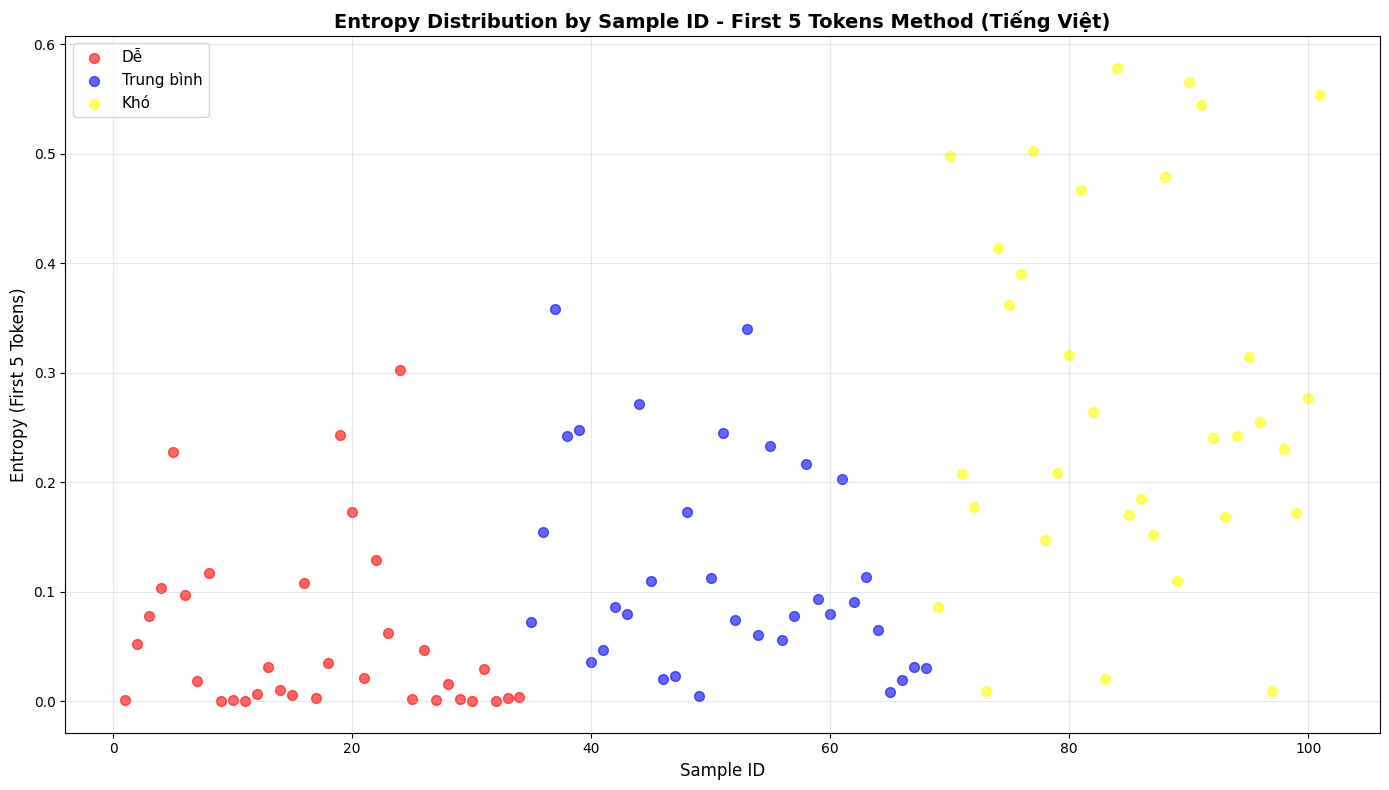

✓ Visualization hoàn tất
  - Đỏ: Câu hỏi dễ (34 samples)
  - Xanh: Câu hỏi trung bình (34 samples)
  - Vàng: Câu hỏi khó (33 samples)


In [8]:
# Lọc các samples hợp lệ
df_valid = df_entropy[df_entropy['entropy'].notna()]

# Color mapping: Red (dễ), Blue (trung_bình), Yellow (khó)
color_map = {
    'dễ': 'red',
    'trung_bình': 'blue',
    'khó': 'yellow'
}

# Tạo scatter plot
fig, ax = plt.subplots(figsize=(14, 8))

for difficulty in ['dễ', 'trung_bình', 'khó']:
    df_diff = df_valid[df_valid['difficulty'] == difficulty]
    if len(df_diff) > 0:
        ax.scatter(
            df_diff['sample_id'],
            df_diff['entropy'],
            c=color_map[difficulty],
            label=difficulty.capitalize().replace('_', ' '),
            alpha=0.6,
            s=50
        )

ax.set_xlabel('Sample ID', fontsize=12)
ax.set_ylabel('Entropy (First 5 Tokens)', fontsize=12)
ax.set_title('Entropy Distribution by Sample ID - First 5 Tokens Method (Tiếng Việt)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Visualization hoàn tất")
print(f"  - Đỏ: Câu hỏi dễ ({len(df_valid[df_valid['difficulty'] == 'dễ'])} samples)")
print(f"  - Xanh: Câu hỏi trung bình ({len(df_valid[df_valid['difficulty'] == 'trung_bình'])} samples)")
print(f"  - Vàng: Câu hỏi khó ({len(df_valid[df_valid['difficulty'] == 'khó'])} samples)")
